# Classification of Pet's Real-Life Images

Lab Assignment from [AI for Beginners Curriculum](https://github.com/microsoft/ai-for-beginners).

Now it's time to deal with more challenging task - classification of the original [Oxford-IIIT Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/). Let's start by loading and visualizing the dataset.

In [1]:
# !wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
# !tar xfz images.tar.gz
# !rm images.tar.gz

import urllib.request
import tarfile
import os

# Download
url = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz"
urllib.request.urlretrieve(url, "images.tar.gz")

# Extract
with tarfile.open("images.tar.gz", "r:gz") as tar:
    tar.extractall()

# Remove
os.remove("images.tar.gz")

C:\Users\sophi\AppData\Local\Temp\ipykernel_39324\3030055327.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


In [4]:
import os
import shutil

# Paths
images_dir = "images"
mat_dir = "mat_files"

# Create folder for .mat files if it doesn't exist
os.makedirs(mat_dir, exist_ok=True)

# Move all .mat files
for fname in os.listdir(images_dir):
    if fname.endswith(".mat"):
        shutil.move(os.path.join(images_dir, fname),
                    os.path.join(mat_dir, fname))

print(f"Moved all .mat files to '{mat_dir}'")

Moved all .mat files to 'mat_files'


We will define generic function to display a series of images from a list:

In [1]:
import matplotlib.pyplot as plt
import os
from PIL import Image
import numpy as np

def display_images(l,titles=None,fontsize=12):
    n=len(l)
    fig,ax = plt.subplots(1,n)
    for i,im in enumerate(l):
        ax[i].imshow(im)
        ax[i].axis('off')
        if titles is not None:
            ax[i].set_title(titles[i],fontsize=fontsize)
    fig.set_size_inches(fig.get_size_inches()*n)
    plt.tight_layout()
    plt.show()

You can see that all images are located in one directory called `images`, and their name contains the name of the class (breed):

In [ ]:
fnames = os.listdir('images')[:5]
display_images([Image.open(os.path.join('images',x)) for x in fnames],titles=fnames,fontsize=30)

To simplify classification and use the same approach to loading images as in the previous part, let's sort all images into corresponding directories:

In [3]:
for fn in os.listdir('images'):
    cls = fn[:fn.rfind('_')].lower()
    os.makedirs(os.path.join('images',cls),exist_ok=True)
    os.replace(os.path.join('images',fn),os.path.join('images',cls,fn))

Let's also define the number of classes in our dataset:

In [2]:
num_classes = len(os.listdir('images'))
num_classes

37

## Preparing dataset for Deep Learning

To start training our neural network, we need to convert all images to tensors, and also create tensors corresponding to labels (class numbers). Most neural network frameworks contain simple tools for dealing with images:
* In Tensorflow, use `tf.keras.preprocessing.image_dataset_from_directory`
* In PyTorch, use `torchvision.datasets.ImageFolder`

As you have seen from the pictures above, all of them are close to square image ratio, so we need to resize all images to square size. Also, we can organize images in minibatches.

In [3]:
# PREPARE THE DATASET
import torch
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.CenterCrop(256), 
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),  
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),   
    transforms.ToTensor(), 
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

dataset = datasets.ImageFolder(root='images', transform=transform)
num_classes = len(dataset.classes)
print(f"Number of classes: {num_classes}")
print(f"Class names: {dataset.classes}")

Number of classes: 37
Class names: ['abyssinia', 'american', 'american_pit_bull', 'basset', 'beagl', 'benga', 'birma', 'bomba', 'boxe', 'british', 'chihuahu', 'egyptian', 'english', 'english_cocker', 'german', 'great', 'havanes', 'japanese', 'keeshon', 'leonberge', 'maine', 'miniature', 'newfoundlan', 'persia', 'pomerania', 'pu', 'ragdol', 'russian', 'saint', 'samoye', 'scottish', 'shiba', 'siames', 'sphyn', 'staffordshire_bull', 'wheaten', 'yorkshire']


Now we need to separate dataset into train and test portions:

In [4]:
# SPLIT INTO TRAIN-TEST DATASETS
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 5912
Test samples: 1478


Now define data loaders:

In [5]:
# WEIGHTED SAMPLER
from torch.utils.data import WeightedRandomSampler

train_targets = [dataset.samples[i][1] for i in train_dataset.indices]

class_counts = np.bincount(train_targets)
class_weights = 1. / class_counts

sample_weights = [class_weights[label] for label in train_targets]

sampler = WeightedRandomSampler(
    weights=sample_weights, 
    num_samples=len(sample_weights), 
    replacement=True
)

In [6]:
# DEFINE DATA LOADERS
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

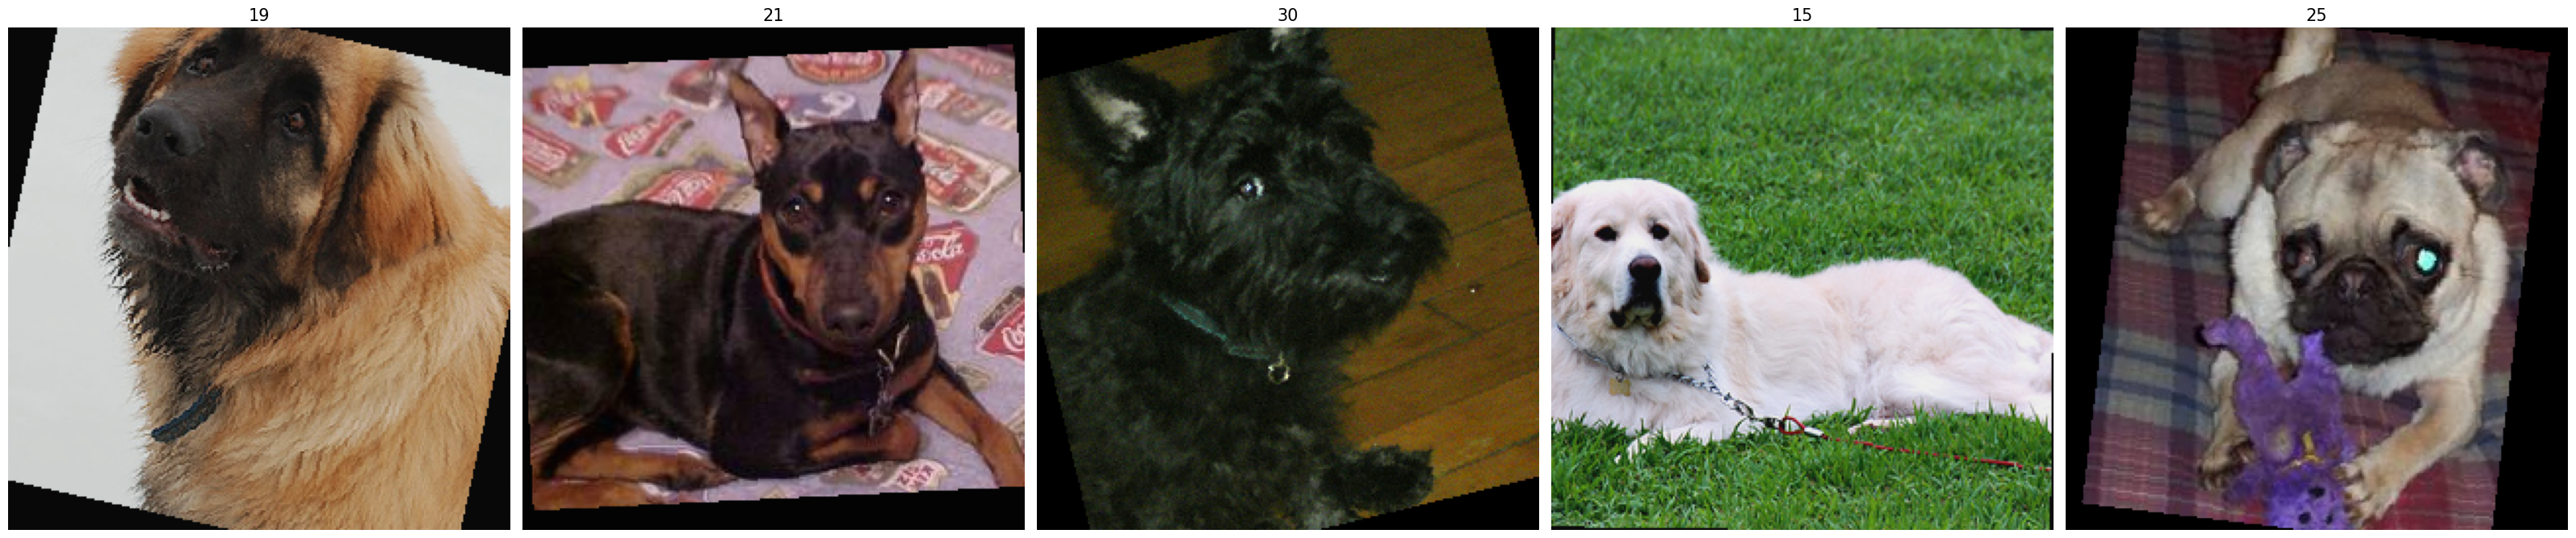

In [ ]:
import torch
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

def unnormalize(img, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]):
    """Unnormalize a PyTorch tensor image."""
    img = img.clone()
    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)
    img = torch.clamp(img, 0, 1)
    return img

images, labels = next(iter(train_loader))
# Unnormalize first
images_unnorm = [unnormalize(img).permute(1, 2, 0) for img in images[:5]]
display_images(images_unnorm, titles=[str(l.item()) for l in labels[:5]], fontsize=15)


In [71]:
# [OPTIONAL] Plot the dataset

## Define a neural network

For image classification, you should probably define a convolutional neural network with several layers. What to keep an eye for:
* Keep in mind the pyramid architecture, i.e. number of filters should increase as you go deeper
* Do not forget activation functions between layers (ReLU) and Max Pooling
* Final classifier can be with or without hidden layers, but the number of output neurons should be equal to number of classes.

An important thing is to get the activation function on the last layer + loss function right:
* In Tensorflow, you can use `softmax` as the activation, and `sparse_categorical_crossentropy` as loss. The difference between sparse categorical cross-entropy and non-sparse one is that the former expects output as the number of class, and not as one-hot vector.
* In PyTorch, you can have the final layer without activation function, and use `CrossEntropyLoss` loss function. This function applies softmax automatically. 

> **Hint:** In PyTorch, you can use `LazyLinear` layer instead of `Linear`, in order to avoid computing the number of inputs. It only requires one `n_out` parameter, which is number of neurons in the layer, and the dimension of input data is picked up automatically upon first `forward` pass.

In [26]:
# DEFINE NEURAL NETWORK ARCHITECTURE
import torch.nn as nn
import torch.nn.functional as F

class PetNet(nn.Module):
    def __init__(self, num_classes):
        super(PetNet, self).__init__()

        # feature extractor
        self.conv_block = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(), 
            nn.MaxPool2d(2),    # 256 => 128

            nn.Conv2d(32, 64, kernel_size=3, padding=1), 
            nn.ReLU(), 
            nn.MaxPool2d(2),    # 128 => 64

            nn.Conv2d(64, 128, kernel_size=3, padding=1), 
            nn.ReLU(), 
            nn.MaxPool2d(2),    # 64 => 32

            nn.Conv2d(128, 256, kernel_size=3, padding=1), 
            nn.ReLU(), 
            nn.MaxPool2d(2),    # 32 => 16
        )

        # classifier
        self.classifier = nn.Sequential(
            nn.Flatten(), 
            # nn.LazyLinear(512), 
            nn.Linear(256*16*16, 1024), 
            nn.ReLU(), 
            nn.Dropout(0.4), 
            nn.Linear(1024, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_block(x)
        x = self.classifier(x)
        return x

## Train the Neural Network

Now we are ready to train the neural network. During training, please collect accuracy on train and test data on each epoch, and then plot the accuracy to see if there is overfitting.

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(dataset.classes)
model = PetNet(num_classes).to(device)
print(device)
# print(model)

cuda


In [32]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=.005, weight_decay=.00005)

In [31]:
# TRAIN THE NEURAL NETWORK
train_acc_hist, test_acc_hist = [], []
num_epochs = 30

for epoch in range(num_epochs):
    # ---- Training ----
    model.train()
    correct, total, running_loss = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_acc = correct / total
    train_acc_hist.append(train_acc)
    
    # ---- Evaluation ----
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    test_acc = correct / total
    test_acc_hist.append(test_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

Epoch [1/30] Train Acc: 0.0325, Test Acc: 0.0298
Epoch [2/30] Train Acc: 0.0244, Test Acc: 0.0311
Epoch [3/30] Train Acc: 0.0262, Test Acc: 0.0386
Epoch [4/30] Train Acc: 0.0291, Test Acc: 0.0237
Epoch [5/30] Train Acc: 0.0254, Test Acc: 0.0237
Epoch [6/30] Train Acc: 0.0267, Test Acc: 0.0332
Epoch [7/30] Train Acc: 0.0244, Test Acc: 0.0304
Epoch [8/30] Train Acc: 0.0279, Test Acc: 0.0189
Epoch [9/30] Train Acc: 0.0257, Test Acc: 0.0257
Epoch [10/30] Train Acc: 0.0257, Test Acc: 0.0304
Epoch [11/30] Train Acc: 0.0281, Test Acc: 0.0230
Epoch [12/30] Train Acc: 0.0267, Test Acc: 0.0257
Epoch [13/30] Train Acc: 0.0225, Test Acc: 0.0244
Epoch [14/30] Train Acc: 0.0276, Test Acc: 0.0257
Epoch [15/30] Train Acc: 0.0242, Test Acc: 0.0250
Epoch [16/30] Train Acc: 0.0250, Test Acc: 0.0298
Epoch [17/30] Train Acc: 0.0250, Test Acc: 0.0223
Epoch [18/30] Train Acc: 0.0244, Test Acc: 0.0264
Epoch [19/30] Train Acc: 0.0281, Test Acc: 0.0311
Epoch [20/30] Train Acc: 0.0218, Test Acc: 0.0271
Epoch [21

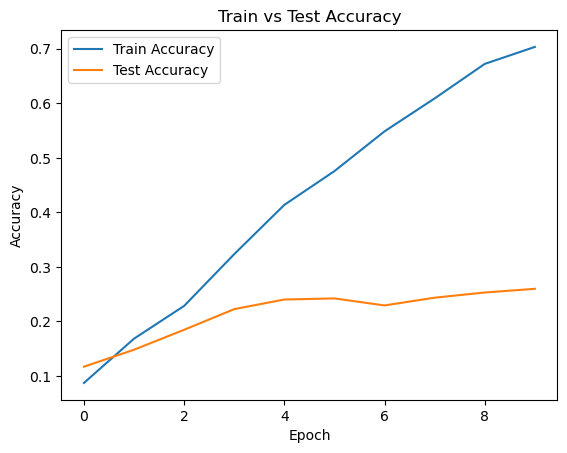

In [89]:
# PLOT THE RESULT: Train and Test Accuracy
plt.plot(train_acc_hist, label="Train Accuracy")
plt.plot(test_acc_hist, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")
plt.legend()
plt.show()

Even if you have done everything correctly, you will probably see that the accuracy is quite low.

## Transfer Learning

To improve the accuracy, let's use pre-trained neural network as feature extractor. Feel free to experiment with VGG-16/VGG-19 models, ResNet50, etc.

> Since this training is slower, you may start with training the model for the small number of epochs, eg. 3. You can always resume training to further improve accuracy if needed.

We need to normalize our data differently for transfer learning, thus we will reload the dataset again using different set of transforms:

In [2]:
# LOAD THE DATASET
# Perform standard transformations for VGG-16/VGG-19 if needed 

Let's load the pre-trained network:

In [3]:
# vgg = ...

Now define the classification model for your problem:
* In PyTorch, there is a slot called `classifier`, which you can replace with your own classifier for the desired number of classes.
* In TensorFlow, use VGG network as feature extractor, and build a `Sequential` model with VGG as first layer, and your own classifier on top

In [52]:
# BUILD MODEL for your problem with your own linear layers

Make sure to set all parameters of VGG feature extractor not to be trainable

In [4]:
# MAKE VGG Layers not trainable

Now we can start the training. Be very patient, as training takes a long time, and our train function is not designed to print anything before the end of the epoch.

In [5]:
# TRAIN THE MODEL

It seems much better now!

## Optional: Calculate Top 3 Accuracy

We can also computer Top 3 accuracy using the same code as in the previous exercise.


In [6]:
# CALCULATE TOP-3 Accuracy of the model